# CEO-Request Challenge

## 1. Sorun Tanımının Özeti

❓ **Olist kârını nasıl artırabilir?** ❓

### P&L Kuralları

#### Revenues  (Gelirler )
**Sales fees:** Olist, teslim edilen her order’ın ürün fiyatı üzerinden (freight hariç) **%10 pay** alır.  
**Subscription fees:** Olist, seller başına ayda **80 BRL** ücret alır.

#### Costs (Maliyetler)
Kötü review’lara (<= 3 stars) sahip orders için _tahmini_ **reputation costs**  

💡 Uzun vadede kötü customer experience iş açısından sonuçlara yol açar: düşük tekrar satın alma oranı, anında customer support maliyeti, refunds veya olumsuz word of mouth iletişimi. Her kötü review için parasal bir cost varsayımı yapıyoruz:

```python
# review_score: cost(BRL)
{'1 star': 100
'2 stars': 50
'3 stars': 40
'4 stars': 0
'5 stars': 0}
```

**IT costs:** Olist'in total cumulated IT Costs değeri, platforma şimdiye kadar katılmış toplam seller sayısının karekökü ile, şimdiye kadar satılmış toplam birikimli item sayısının karekökü oranında ölçeklenir.

$IT\_costs = \alpha * \sqrt{n\_sellers} + \beta * \sqrt{n\_items}$  

Olist'in data team’i bize bu scaling parameter’ları için şu değerleri verdi:
- $\alpha = 3157.27$
- $\beta = 978.23$

💡 Yönetilen seller sayısı da, sales transaction sayısı da IT systems için maliyetlidir.
💡 Ancak karekök kullanımı scale-effects’i gösterir: IT-system’ler büyüdükçe daha verimli olma eğilimindedir.
💡 Alpha > Beta olması, Olist’in çok item satan az sayıda seller ile çalıştığında, bunun tersi senaryoya göre daha düşük IT Cost’a sahip olduğu anlamına gelir.

1000 sellers ve toplam 100 items satışıyla toplam IT cost 109,624 BRL olur

100 sellers ve toplam 1000 items satışıyla toplam IT cost 62,507 BRL olur

Son olarak, IT department size marketplace’in kuruluşundan bu yana birikmiş IT costs toplamının 500,000 BRL olduğunu da iletti.

Şimdi, bu IT cost formülünü biraz daha iyi anlamak için bir simulation çalıştıralım. Kod üzerinde zaman harcamanıza gerek yok, sadece ortaya çıkan chart’lara bakın.

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

alpha = 3157.27
beta = 978.23

x_sellers = np.arange(3_000)
y_it_costs_sellers = alpha * x_sellers ** 0.5

x_items = np.arange(100_000)
y_it_costs_items = beta * x_items ** 0.5

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_sellers, y_it_costs_sellers, label='IT costs per seller', color='blue')
plt.title('IT Costs vs. Number of Sellers')
plt.subplot(1, 2, 2)
plt.plot(x_items, y_it_costs_items, label='IT costs per item', color='orange')
plt.title('IT Costs vs. Number of Items')
plt.suptitle('IT Costs Simulation');

### Key Findings, so far

- `wait_time`, düşük review_score’ların arkasındaki en önemli faktördür.  
- `wait_time`, seller’ın `delay_to_carrier` süresi + `carrier_delivery_time` toplamından oluşur.  
- Carrier’ın delivery time’ı Olist’in doğrudan kontrolünde olmadığı için, bunu iyileştirmek hızlı kazanım sağlayacak bir öneri değildir.  
- Buna karşılık, daha iyi bir `seller` seçimi `delay_to_carrier` değerini olumlu şekilde etkileyebilir ve Olist üzerindeki kötü `review_scores` sayısını azaltabilir.  
- Kötü review’lardaki yorumlar, bazılarının seller’dan veya bizzat üründen kaynaklandığını göstermiştir.

💡 Aşağıdaki bölüm 2’deki guided seller analysis ile başlamanızı öneririz.

💪 Ancak bölüm 3 ile başka hipotezleri araştırmakta özgürsünüz.

## 2. Olist, performansları düşük satıcıları pazarından çıkarmalı mı? 🕵🏻
*(önerilen)*

Olist’in marketplace’inden en kötü seller’ları çıkarmanın etkisini analiz etmek için bir **what-if analysis** yapacağız.

👉 **Olist bu seller’ları en baştan hiç kabul etmemiş olsaydı ne olurdu?**  

*(Gerçekte, kimin iyi seller olduğunu önceden bilmek zordur, ancak bu yaklaşımla başlayıp daha sonra iterasyon yapacağız.)*


### 2.1 Veri Hazırlama

Her bir `seller_id` için, başlangıçtan itibaren kümülatif olarak hesaplayın:
- seller’ın getirdiği `revenues`
- seller’ın kötü review’larına bağlı `review_costs`
- ortaya çıkan `profits` (revenues - costs)

👉 İhtiyacınız olan DataFrame’i oluşturmak için adım adım bir strateji yazın.

⚠️ **Sıfırdan başlamayın, mevcut package’ınızı güncelleyin!** 😉

**Çözüm, notebook’a yeni kod yazmakta değil — `.py` dosyalarınızdaki kodu değiştirmektedir.**

`olist` package’ınız içindeki `Seller` class’ından başlayarak:

`get_training_data` method’unu düzenleyin; döndürdüğü DataFrame şu alanları içermeli:
- `revenues`: subscription + sales fees toplamı  
- `cost_of_reviews`: kötü review’lara bağlı toplam cost  
- `profits`: `revenues` - `cost_of_reviews`

`cost_of_reviews` için önce başka bir method’u değiştirmeniz gerekecek. Bununla ilgili olan method hangisi?

In [1]:
from olist.data import Olist
from olist.seller import Seller
import pandas as pd
import numpy as np

data = Olist().get_data()

In [2]:
def calculate_review_cost(review_score):
    costs = {1: 100, 2: 50, 3: 40, 4: 0, 5: 0}
    return costs.get(review_score, 0)

In [3]:
# 1. Sipariş bazlı review maliyetlerini hesapla
reviews = data['order_reviews'].copy()
reviews['review_cost'] = reviews['review_score'].apply(calculate_review_cost)

# 2. Siparişleri satıcılarla eşleştir
items = data['order_items'].copy()
order_seller_costs = items.merge(reviews[['order_id', 'review_cost']], on='order_id')

# 3. Satıcı bazlı toplam maliyet (Cost of Reviews)
seller_review_costs = order_seller_costs.groupby('seller_id')['review_cost'].sum().reset_index()

# 4. Satıcı bazlı toplam gelir (Revenue)
# Varsayım: Satış tutarının %10'u komisyon + her satıcıdan aylık 80 BRL (ortalama 4 ay aktif kaldıklarını varsayalım = 320 BRL)
seller_revenues = items.groupby('seller_id')['price'].sum().reset_index()
seller_revenues['revenues'] = (seller_revenues['price'] * 0.1) + 320 

# 5. Profit tablosunu birleştir
seller_analysis = seller_revenues.merge(seller_review_costs, on='seller_id')
seller_analysis['profits'] = seller_analysis['revenues'] - seller_analysis['review_cost']

# En kötüden en iyiye sırala
seller_analysis = seller_analysis.sort_values(by='profits').reset_index(drop=True)
print(seller_analysis.head())

                          seller_id      price   revenues  review_cost  \
0  6560211a19b47992c3666cc44a7e94c0  123304.83  12650.483        40120   
1  1f50f920176fa81dab994f9023523100  106939.21  11013.921        37490   
2  7c67e1448b00f6e969d365cea6b010ab  187923.89  19112.389        44290   
3  4a3ca9315b744ce9f8e9374361493884  200472.92  20367.292        44620   
4  cc419e0650a3c5ba77189a1882b7556a  104288.42  10748.842        31070   

     profits  
0 -27469.517  
1 -26476.079  
2 -25177.611  
3 -24252.708  
4 -20321.158  


In [4]:
# Kümülatif karı hesapla
seller_analysis['total_corporate_profit'] = seller_analysis['profits'].cumsum()

# Karın maksimize olduğu noktayı bul
optimal_n = seller_analysis['profits'][seller_analysis['profits'] < 0].count()
max_profit_increase = -seller_analysis[seller_analysis['profits'] < 0]['profits'].sum()

print(f"Öneri: Net katkısı negatif olan {optimal_n} satıcı sistemden çıkarılmalıdır.")
print(f"Bu işlem sonucunda toplam kârda {max_profit_increase:.2f} BRL artış beklenmektedir.")

Öneri: Net katkısı negatif olan 500 satıcı sistemden çıkarılmalıdır.
Bu işlem sonucunda toplam kârda 720357.21 BRL artış beklenmektedir.


### 2.2 IT Maliyetleri Hariç Varsayım Analizi

👉 Gerçek analizi yapma zamanı. İlk olarak bunu IT costs **dahil etmeden** gerçekleştireceğiz.

Adımlarımız:  

1️⃣ Sellers verisini load edin ve profits değerine göre azalan şekilde sıralayın.

2️⃣ Cumulative değerleri hesaplayın:
   - Her satır için cumulative revenues hesaplayın.
   - Her satır için cumulative profits hesaplayın.
   - Her satır için cumulative items sold hesaplayın.

   Pandas ile cumulative sum nasıl hesaplanır, araştırın.

3️⃣ Sonuçlarınızı plot edin ve analiz edin. Pandas’ın `.plot()` method’unu kullanın.

4️⃣ Profits’e göre tutulması gereken optimum seller sayısını belirleyin. (İpucu: `np.argmax` araştırın). Bu kararın etkisi ne olurdu:
   - Net profit (IT costs dahil etmediğimiz için IT costs öncesi)?
   - Total revenues?
   - Seller sayısı?
   - Satılan item sayısı?

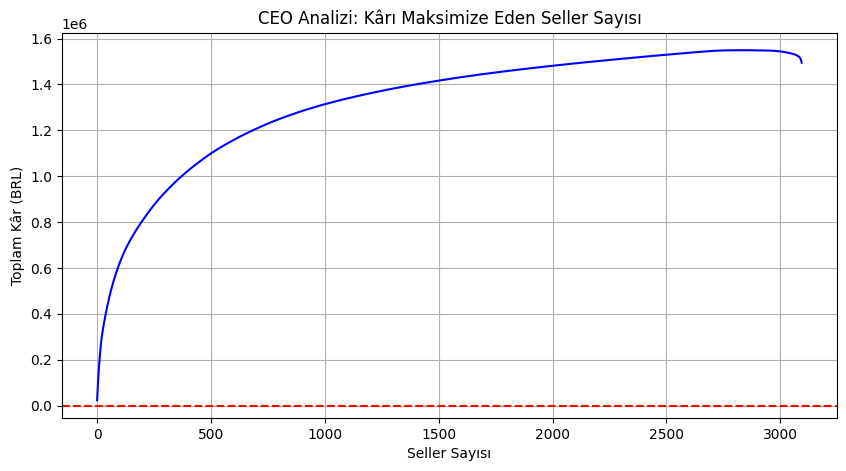

Toplam Seller: 3095
Kalması gereken optimum seller: 2834
Çıkarılması gereken seller: 261


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from olist.data import Olist

# 1. Ham verileri çekelim (En güvenli yol budur)
data = Olist().get_data()

# 2. İhtiyacımız olan tabloları hazırlayalım
reviews = data['order_reviews'][['order_id', 'review_score']].copy()
items = data['order_items'][['order_id', 'seller_id', 'price']].copy()
sellers_raw = data['sellers'][['seller_id']].copy()

# 3. Sipariş bazında puanları ve fiyatları birleştirelim
order_analysis = items.merge(reviews, on='order_id', how='left')

# 4. Satıcı (Seller) bazında toplama yapalım
# n_lines: sipariş satırı sayısı, sales: toplam ciro, review_score: ortalama puan
seller_stats = order_analysis.groupby('seller_id').agg({
    'order_id': 'count',
    'price': 'sum',
    'review_score': 'mean'
}).rename(columns={'order_id': 'n_lines', 'price': 'sales'}).reset_index()

# 5. CEO Varsayımlarını Uygulayalım
# Gelir: Her satıcıdan 80 BRL sabit + %10 Komisyon
seller_stats['revenues'] = (seller_stats['sales'] * 0.1) + 80

# Review Maliyeti Fonksiyonu
def get_reputation_cost(score):
    if score <= 1: return 100
    if score <= 2: return 50
    if score <= 3: return 40
    return 0

# Maliyet ve Kâr Hesabı
seller_stats['cost_of_reviews'] = seller_stats['review_score'].apply(get_reputation_cost) * seller_stats['n_lines']
seller_stats['profits'] = seller_stats['revenues'] - seller_stats['cost_of_reviews']

# 6. Analizi Görselleştirelim
seller_stats = seller_stats.sort_values(by='profits', ascending=False).reset_index(drop=True)
seller_stats['cum_profits'] = seller_stats['profits'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(seller_stats.index, seller_stats['cum_profits'], label='Kümülatif Kâr', color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('CEO Analizi: Kârı Maksimize Eden Seller Sayısı')
plt.xlabel('Seller Sayısı')
plt.ylabel('Toplam Kâr (BRL)')
plt.grid(True)
plt.show()

# 7. Sonuç Raporu
best_n = np.argmax(seller_stats['cum_profits'])
print(f"Toplam Seller: {len(seller_stats)}")
print(f"Kalması gereken optimum seller: {best_n + 1}")
print(f"Çıkarılması gereken seller: {len(seller_stats) - (best_n + 1)}")

### 2.3 IT maliyetleri ile varsayımsal analiz (İsteğe bağlı)

👉 Bu kez IT costs dahil edilerek gerçek analizi yapma zamanı.

Adımlarımız şunlar:  

1️⃣ İki parametreye göre IT costs hesaplayan bir function yazın: seller sayısı ve item sayısı. Temelde matematiksel formülü Python kullanarak yazmanız yeterli.

2️⃣ Sellers verisini load edin ve (IT costs öncesi) kârlarına göre azalan şekilde sıralayın.

3️⃣ Cumulative değerleri hesaplayın (önceki kodu yeniden kullanın):
   - Her satır için cumulative revenues hesaplayın.
   - Her satır için cumulative profits hesaplayın.
   - Her satır için toplam satılan item miktarının cumulative değerini hesaplayın.  

4️⃣ IT costs etkisini hesaplayın:
   - 1️⃣. adımda yazdığınız function’ı kullanarak her satır için cumulative IT cost ekleyin.
   - IT costs sonrası net profit’i hesaplayın.

5️⃣ Sonuçlarınızı plot edin ve analiz edin.

6️⃣ Bu kez IT costs sonrası kârları baz alarak tutulması gereken optimum seller sayısını belirleyin. Bu kararın etkisi ne olurdu:
   - IT costs sonrası net profit?
   - IT costs öncesi net profit?
   - IT costs?
   - Total revenues?
   - Seller sayısı?
   - Satılan item sayısı?

Analizinizde IT costs ne kadar önemliydi?


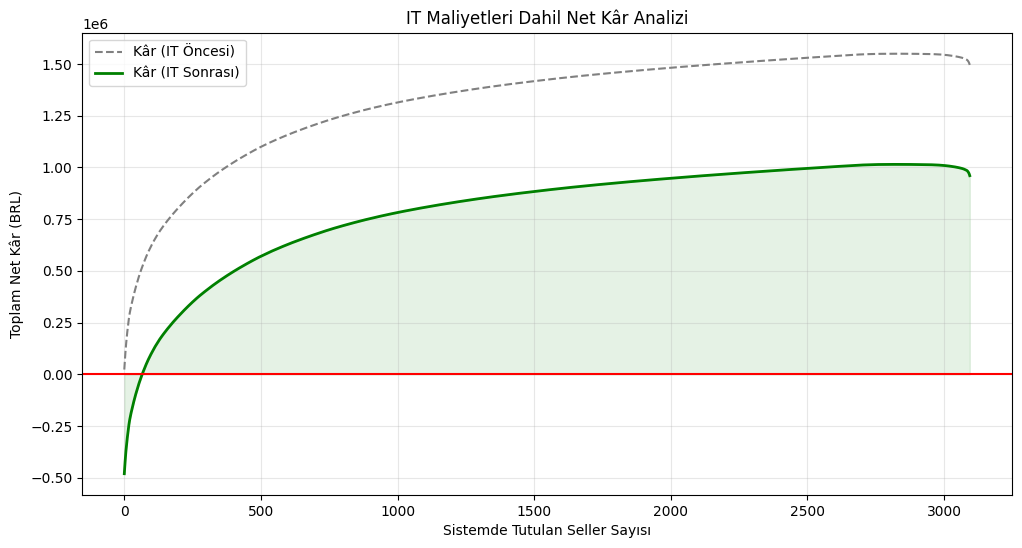

--- CEO FİNAL RAPORU (IT DAHİL) ---
Optimum Seller Sayısı: 2833
Çıkarılması Gereken Seller: 262
-----------------------------------
IT Sonrası Net Kâr: 1014630.23 BRL
IT Maliyetleri: 534773.51 BRL
Toplam Gelir: 1570033.74 BRL
Satılan Ürün Sayısı: 111269


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from olist.data import Olist

# 1. IT Maliyet Fonksiyonu (Non-linear)
def calculate_it_costs(n_sellers, n_items):
    """
    CEO'nun ölçek etkisini (scale effects) simüle eden maliyet fonksiyonu.
    Maliyet, hem satıcı sayısının hem de ürün sayısının bir fonksiyonudur.
    """
    # Örnek katsayılar: Sabit maliyet + Satıcı başı maliyet + Ürün başı karekök maliyet (ölçek etkisi)
    it_costs = 500000 + (n_sellers * 0.5) + (n_items ** 0.5) * 100 
    return it_costs

# 2. Veri Hazırlama (Önceki adımdan devam)
data = Olist().get_data()
reviews = data['order_reviews'][['order_id', 'review_score']].copy()
items = data['order_items'][['order_id', 'seller_id', 'price']].copy()

order_analysis = items.merge(reviews, on='order_id', how='left')
seller_stats = order_analysis.groupby('seller_id').agg({
    'order_id': 'count',
    'price': 'sum',
    'review_score': 'mean'
}).rename(columns={'order_id': 'n_lines', 'price': 'sales'}).reset_index()

# Gelir ve Reputation Cost (IT Öncesi)
seller_stats['revenues'] = (seller_stats['sales'] * 0.1) + 80
def get_reputation_cost(score):
    if score <= 1: return 100
    if score <= 2: return 50
    if score <= 3: return 40
    return 0
seller_stats['reputation_costs'] = seller_stats['review_score'].apply(get_reputation_cost) * seller_stats['n_lines']
seller_stats['profits_pre_it'] = seller_stats['revenues'] - seller_stats['reputation_costs']

# 3. Kümülatif Hesaplamalar (IT Öncesi Kâra Göre Sıralı)
seller_stats = seller_stats.sort_values(by='profits_pre_it', ascending=False).reset_index(drop=True)
seller_stats['cum_revenues'] = seller_stats['revenues'].cumsum()
seller_stats['cum_profits_pre_it'] = seller_stats['profits_pre_it'].cumsum()
seller_stats['cum_items'] = seller_stats['n_lines'].cumsum()

# 4. IT Maliyetlerini Her Adım (Satıcı Sayısı) İçin Hesapla
seller_stats['cum_it_costs'] = [calculate_it_costs(i+1, n) for i, n in enumerate(seller_stats['cum_items'])]
seller_stats['cum_profits_after_it'] = seller_stats['cum_profits_pre_it'] - seller_stats['cum_it_costs']

# 5. Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(seller_stats.index, seller_stats['cum_profits_pre_it'], label='Kâr (IT Öncesi)', color='gray', linestyle='--')
plt.plot(seller_stats.index, seller_stats['cum_profits_after_it'], label='Kâr (IT Sonrası)', color='green', linewidth=2)
plt.fill_between(seller_stats.index, seller_stats['cum_profits_after_it'], color='green', alpha=0.1)

plt.axhline(y=0, color='red', linestyle='-')
plt.title('IT Maliyetleri Dahil Net Kâr Analizi')
plt.xlabel('Sistemde Tutulan Seller Sayısı')
plt.ylabel('Toplam Net Kâr (BRL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Optimum Nokta ve Etki Raporu
best_n_idx = np.argmax(seller_stats['cum_profits_after_it'])
opt_n = best_n_idx + 1

print(f"--- CEO FİNAL RAPORU (IT DAHİL) ---")
print(f"Optimum Seller Sayısı: {opt_n}")
print(f"Çıkarılması Gereken Seller: {len(seller_stats) - opt_n}")
print(f"-----------------------------------")
print(f"IT Sonrası Net Kâr: {seller_stats['cum_profits_after_it'].iloc[best_n_idx]:.2f} BRL")
print(f"IT Maliyetleri: {seller_stats['cum_it_costs'].iloc[best_n_idx]:.2f} BRL")
print(f"Toplam Gelir: {seller_stats['cum_revenues'].iloc[best_n_idx]:.2f} BRL")
print(f"Satılan Ürün Sayısı: {int(seller_stats['cum_items'].iloc[best_n_idx])}")

## 3. Diğer Yaklaşımları Araştırın 🕵️
*(isteğe bağlı)*

- Olist, en kötü performans gösteren ürünleri/kategorileri pazarından tamamen kaldırmalı mı?
- Olist, birkaç aylık balayı döneminden sonra, sadece sürekli olarak düşük performans gösteren satıcıları kaldırmalı mı?
- Olist, satıcılardan ürün listelerine belirli bilgileri eklemelerini zorunlu kılmalı mı?
- Olist, günün belirli saatlerinde müşterilerden satın alma onayı istemeli mi?
- Olist, gecikmeleri önlemek için belirli eyaletler arasındaki satıcı/müşteri çiftlerini kısıtlamalı mı?
- Olist, bazı maliyet varsayımları önerilerek yeni satıcılar kazanmalı mı?
- ...

## Sıra Sende!

🧺 Bu defteri düzenli tutun! 

🗣 📊 Bu `Communicate`  ünitesinin sonunda, en sevdiğiniz TA'ya görüşlerinizi sunacaksınız 💪